In [26]:
!pip3 install -U langgraph langchain langchain-openai langchainhub langchain-community --break-system-packages

  Using cached langchain_openai-1.1.10-py3-none-any.whl.metadata (3.1 kB)
  Attempting uninstall: langchain-openai
    Found existing installation: langchain-openai 0.3.35
    Uninstalling langchain-openai-0.3.35:
      Successfully uninstalled langchain-openai-0.3.35


### Understanding Tools in ReAct

Tools are the “acting” part of ReAct, letting agents do more than text generation.

##### 1. Web Search Tool
Use Tavily as the external search tool. Get an API key from https://app.tavily.com/sign-in, then set it in code:

In [2]:
import warnings 
warnings.filterwarnings('ignore')

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
from dotenv import load_dotenv

load_dotenv()

import os
import json

# Initialize the Tavily search tool
search = TavilySearchResults()

@tool
def search_tool(query: str):
    """
    Search the web for information using Tavily API.

    :param query: The search query string
    :return: Search results related to the query
    """
    return search.invoke(query)

/var/folders/td/rtvtvvjn3x1gfqswnc7bb6hm0000gn/T/ipykernel_40707/1312173223.py:14: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults()


##### Theory Behind Web Search Tools
- Retrieve real-time information  
- Bypass LLM knowledge-cutoff limits  
- Return structured results the agent can reason over  

##### Testing the Search Tool

In [3]:
search_tool.invoke("What's the weather like in Tokyo today?")

[{'title': 'Weather Forecast for Tokyo for Sunday 8 March - Metcheck.com',
  'url': 'https://www.metcheck.com/WEATHER/dayforecast.asp?location=Tokyo&locationID=948135&lat=35.689500&lon=139.691710&dateFor=08/03/2026',
  'content': '| |  |  | Hazy Sunshine/High Cloud Expected Soon With Temperature Of 5°c 5°c |  Soon) | |  |  | Starting Hazy Sunshine/High Cloud But Fair Later With Max Temp Of 9°c And Min Temp Of 2°c 9°c 2°c |  Mon) | |  |  | Starting Showers But Partly Cloudy Later With Max Temp Of 7°c And Min Temp Of 4°c 7°c 4°c |  Tue) | |  |  | Starting Partly Cloudy But Showers Later With Max Temp Of 9°c And Min Temp Of 3°c 9°c 3°c |  Wed) | |  |  | Light Rain For Most Of The Day With Max Temp Of 7°c And Min Temp Of 2°c 7°c 2°c |  Thu) | |  |  | Partly Cloudy For Most Of The Day With Max Temp Of 6°c And Min Temp Of 5°c 6°c 5°c |  Fri) | |  |  | Hazy Sunshine/High Cloud For Most Of The Day With Max Temp Of 13°c And Min Temp Of 5°c 13°c 5°c |  Sat) | |  |  | Starting Hazy Sunshine/High 

This test demonstrates how the agent can access current information that wasn't available during training.

##### 2. Clothing Recommendation Tool


In [4]:
@tool
def recommend_clothing(weather: str) -> str:
    """
    Returns a clothing recommendation based on the provided weather description.

    This function examines the input string for specific keywords or temperature indicators 
    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles 
    common weather conditions like snow, rain, heat, and cold by providing simple and practical 
    clothing advice.

    :param weather: A brief description of the weather (e.g., "Overcast, 64.9°F")
    :return: A string with clothing recommendations suitable for the weather
    """
    weather = weather.lower()
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."

**Why this Tool Matters:**
- Demonstrates domain-specific reasoning
- Shows how tools can process and interpret data from other tools
- Illustrates the composability of ReAct systems

##### Creating the Tool Registry

In [5]:
tools=[search_tool,recommend_clothing]

tools_by_name={ tool.name:tool for tool in tools}

This registry allows the agent to dynamically select and invoke the appropriate tool based on the task at hand.

### Setting Up the Language Model

##### Initializing the AI Model


In [7]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

model = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="Qwen/Qwen3.5-397B-A17B:novita"
)

##### Creating the System Prompt


In [8]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
You are a helpful AI assistant that thinks step-by-step and uses tools when needed.

When responding to queries:
1. First, think about what information you need
2. Use available tools if you need current data or specific capabilities  
3. Provide clear, helpful responses based on your reasoning and any tool results

Always explain your thinking process to help users understand your approach.
"""),
    MessagesPlaceholder(variable_name="scratch_pad")
])

**The System Prompt's Role:**
- Defines the agent's behavior and personality
- Establishes the reasoning pattern (think → act → observe)
- Encourages transparency in the decision-making process

##### Binding Tools to the Model

In [9]:
model_react=chat_prompt|model.bind_tools(tools)

This creates a model that can:
- Understand when to use tools
- Generate properly formatted tool calls
- Process tool results in context

### Understanding Agent State

##### What is Agent State?

In ReAct, state management is crucial, as the agent must maintain context across multiple reasoning and acting steps.


In [11]:
from typing import (Annotated,Sequence,TypedDict)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    """The state of the agent."""

    # add_messages is a reducer
    # See https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    messages: Annotated[Sequence[BaseMessage], add_messages]

**Key Concepts:**
- **State**: Contains the conversation history and context.
- **Reducer**: `add_messages` automatically handles adding new messages to the conversation.
- **Type Safety**: TypedDict ensures our state structure is well-defined.

##### Demonstrating State Management

In [12]:
# Example conversation flow:
state: AgentState = {"messages": []}

# append a message using the reducer properly
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Hi")])
print("After greeting:", state["messages"])

# add another message (e.g. a question)
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Weather in NYC?")])
print("After question:", state)

After greeting: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='b9daed73-fd1b-4a82-b0e4-bd0c92de098a')]
After question: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='b9daed73-fd1b-4a82-b0e4-bd0c92de098a'), HumanMessage(content='Weather in NYC?', additional_kwargs={}, response_metadata={}, id='b7c91570-4e66-4a82-998e-730261ab8156')]}


### Manual ReAct Execution (Understanding the Flow)

Before building the automated graph, let's manually step through a ReAct cycle to understand what happens:

##### Step 1: Initial Query Processing


In [13]:
dummy_state: AgentState = {
    "messages": [HumanMessage( "What's the weather like in Zurich, and what should I wear based on the temperature?")]}

response = model_react.invoke({"scratch_pad":dummy_state["messages"]})

dummy_state["messages"]=add_messages(dummy_state["messages"],[response])

##### Step 2: Tool Execution

In [14]:
tool_call = response.tool_calls[-1]
print("Tool call:", tool_call)

tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
print("Tool result preview:", tool_result[0]['title'])

tool_message = ToolMessage(
    content=json.dumps(tool_result),
    name=tool_call["name"],
    tool_call_id=tool_call["id"]
)
dummy_state["messages"] = add_messages(dummy_state["messages"], [tool_message])

Tool call: {'name': 'search_tool', 'args': {'query': 'current weather Zurich Switzerland temperature'}, 'id': 'call_eb767f5db2014a7686a1c6c6', 'type': 'tool_call'}
Tool result preview: Zürich, Switzerland: 1 hour detailed weather forecast for 2026-03-08


##### Step 3: Processing Results and Next Action

In [15]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
dummy_state['messages'] = add_messages(dummy_state['messages'], [response])

# check if the model wants to use another tool
if response.tool_calls:
    tool_call = response.tool_calls[0]
    tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=json.dumps(tool_result),
        name=tool_call["name"],
        tool_call_id=tool_call["id"]
    )
    dummy_state['messages'] = add_messages(dummy_state['messages'], [tool_message])

##### Step 4: Final Response Generation

In [16]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
print("Final response generated:", response.content is not None)
print("More tools needed:", bool(response.tool_calls))

Final response generated: True
More tools needed: False


### Automating ReAct with Graphs

##### Why Use Graphs?

Manual ReAct execution is educational but impractical for real applications. LangGraph automates this process with a state machine that handles the reasoning loop automatically.

##### Building the Core Functions

In [17]:
def tool_node(state: AgentState):
    """Execute all tool calls from the last message in the state."""
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

In [18]:
def call_model(state: AgentState):
    """Invoke the model with the current conversation state."""
    response = model_react.invoke({"scratch_pad": state["messages"]})
    return {"messages": [response]}

Decision Logic

In [19]:
def should_continue(state: AgentState):
    """Determine whether to continue with tool use or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

##### Constructing the State Graph

In [20]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Add edges between nodes
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Add conditional logic
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",  # If tools needed, go to tools node
        "end": END,          # If done, end the conversation
    },
)

# Set entry point
workflow.set_entry_point("agent")

# Compile the graph
graph = workflow.compile()

##### Visualizing the Graph

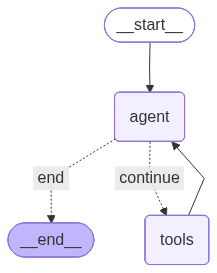

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### Running the Complete ReAct Agent

##### Final Execution


In [22]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?")]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What's the weather like in Zurich, and what should I wear based on the temperature?
================================== Ai Message ==================================
Tool Calls:
  search_tool (call_ac07a3be93a547a1a867809f)
 Call ID: call_ac07a3be93a547a1a867809f
  Args:
    query: current weather Zurich Switzerland temperature
================================= Tool Message =================================
Name: search_tool

[{"title": "Weather Forecast for Zurich for Sunday 8 March", "url": "https://www.metcheck.com/WEATHER/dayforecast.asp?location=Zurich&locationID=299125&lat=43.421630&lon=-81.627730&dateFor=08/03/2026", "content": "Light Snow Later With Max Temp Of 8\u00b0c And Min Temp Of -5\u00b0c 8\u00b0c -5\u00b0c |  Sun) | [...] | 23:00 | 5 \u00b0c | 3 \u00b0c | 0% | 0.0mm | 100% |  | 8mph | 13mph | 84% | 0 |  |\n|  |  | |  |  |  |  |  |  |  |  |  | [...] | |  |  | Partly Cloudy Expected Soon With

### The Complete ReAct Cycle

The final execution demonstrates the full ReAct pattern:

1. **Reasoning**: "I need current weather data for Zurich".
2. **Acting**: Calls search_tool("Zurich weather today").
3. **Observing**: Processes search results, extracts temperature.
4. **Reasoning**: "Now I need clothing recommendations for this temperature".
5. **Acting**: Calls recommend_clothing("temperature from search").
6. **Observing**: Gets clothing suggestions.
7. **Reasoning**: "I can now provide a complete answer".
8. **Final Response**: Synthesizes weather info and clothing recommendations.

### What Makes ReAct Powerful

1. **Transparency**: You can see the agent's reasoning process.
2. **Adaptability**: The agent can handle unexpected results and change course.
3. **Extensibility**: It's easy to add new tools and capabilities.
4. **Reliability**: The structured approach reduces hallucination and improves accuracy



### 📝 Exercise 1 - Build a Calculator Tool

**Objective:** Create a mathematical calculator tool that can handle complex calculations.

Your task is to create a calculator tool that can perform mathematical operations. This tool should be able to handle expressions like "2 + 3 * 4", "sqrt(16)", and "sin(π/2)".

##### Instructions:
1. Create a tool called `calculator_tool` using the `@tool` decorator.
2. The tool should accept a mathematical expression as a string.
3. Use Python's `eval()` function carefully (or better yet, use the `ast` module for safety).
4. Test your tool with various mathematical expressions.
5. Add your tool to the tools list and test it with the ReAct agent.

##### Starter Code:


In [32]:
import math
import ast, operator as op
import operator
from langchain_classic.agents import initialize_agent, AgentType
from dotenv import load_dotenv

load_dotenv()
import os

llm = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="Qwen/Qwen3.5-397B-A17B:novita"
)

OPS = {ast.Add: op.add, ast.Sub: op.sub, ast.Mult: op.mul, ast.Div: op.truediv, ast.Pow: op.pow}

def safe_eval(expr: str):
    def walk(n):
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)):
            return n.value
        if isinstance(n, ast.BinOp) and type(n.op) in OPS:
            return OPS[type(n.op)](walk(n.left), walk(n.right))
        if isinstance(n, ast.UnaryOp) and isinstance(n.op, ast.USub):
            return -walk(n.operand)
        raise ValueError("Unsupported expression")
    return walk(ast.parse(expr, mode="eval").body)

@tool
def calculator_tool(expression: str) -> str:
    """
    Safely evaluate mathematical expressions.
    
    :param expression: A mathematical expression as a string (e.g., "2 + 3 * 4")
    :return: The result of the calculation
    """
    # TODO: Implement safe mathematical evaluation
    # Hint: You can use ast.literal_eval for simple expressions
    # or create a safe evaluator for more complex math
    return str(safe_eval(expression))

# TODO: Add calculator_tool to your tools list
agent = initialize_agent(
    tools=[calculator_tool],
    llm=llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
    handle_parsing_errors=True,
)

# TODO: Test with the agent: "What's 15% of 250 plus the square root of 144?"
agent.invoke("What's 15% of 250 plus the square root of 144?")



> Entering new AgentExecutor chain...
Action:
```
{
  "action": "calculator_tool",
  "action_input": "0.15 * 250 + 144**0.5"
}
```
Observation: 49.5
Thought:Action:
```
{
  "action": "Final Answer",
  "action_input": "49.5"
}
```

> Finished chain.


{'input': "What's 15% of 250 plus the square root of 144?", 'output': '49.5'}

### 📝 Exercise 2 - Create a News Summary Tool

**Objective:** Build a tool that can fetch and summarize recent news articles.

Create a news summarization tool that works with the existing search functionality. This tool should take search results and create concise summaries of news articles.

##### Instructions:
1. Create a `news_summarizer_tool` that takes news content and creates summaries.
2. The tool should extract key information: headline, date, main points.
3. Format the output in a readable way.
4. Test it by asking the agent to "search for recent AI news and summarize the top 3 articles".

##### Starter Code:


In [33]:
@tool
def news_summarizer_tool(news_content: str) -> str:
    """
    Summarize news articles from search results.
    
    :param news_content: Raw news content or search results
    :return: A formatted summary of the news
    """
    # TODO: Parse the news content
    # TODO: Extract key information (headlines, dates, main points)
    # TODO: Format into a readable summary
    # Hint: You might want to split by articles and process each one
    items = []
    try:
        data = json.loads(news_content)
        rows = data.get("results", data) if isinstance(data, dict) else data
        if isinstance(rows, list):
            for r in rows[:5]:
                items.append((
                    r.get("title", "Untitled"),
                    r.get("published_date") or r.get("date") or "Unknown date",
                    (r.get("content") or r.get("snippet") or "")[:180],
                ))
    except Exception:
        blocks = [b.strip() for b in re.split(r"\n\s*\n", news_content) if b.strip()][:5]
        for b in blocks:
            lines = [x.strip() for x in b.splitlines() if x.strip()]
            items.append((lines[0] if lines else "Untitled", "Unknown date", " ".join(lines[1:])[:180]))

    if not items:
        return "No news found."

    return "\n".join(
        ["News Summary:"] +
        [f"{i+1}. {t} ({d})\n   - {s}" for i, (t, d, s) in enumerate(items)]
    )

# TODO: Add to tools list and test with:
# "Find recent news about artificial intelligence and give me a summary"
agent = initialize_agent(
    tools=[news_summarizer_tool],
    llm=llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
    handle_parsing_errors=True,
)

# TODO: Test with the agent: "What's 15% of 250 plus the square root of 144?"
agent.invoke("What's 15% of 250 plus the square root of 144?")



> Entering new AgentExecutor chain...
Action:
```
{
  "action": "Final Answer",
  "action_input": "Let me calculate this step by step:\n\n1. 15% of 250 = 0.15 × 250 = 37.5\n2. Square root of 144 = 12\n3. 37.5 + 12 = 49.5\n\nThe answer is **49.5**"
}
```

> Finished chain.


{'input': "What's 15% of 250 plus the square root of 144?",
 'output': 'Let me calculate this step by step:\n\n1. 15% of 250 = 0.15 × 250 = 37.5\n2. Square root of 144 = 12\n3. 37.5 + 12 = 49.5\n\nThe answer is **49.5**'}

### Testing Your Solutions

For each exercise, test your implementation with these commands:


In [34]:
# Exercise 1 Test
inputs = {"messages": [HumanMessage(content="Calculate 15% of 250 plus the square root of 144")]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Calculate 15% of 250 plus the square root of 144
================================== Ai Message ==================================

I can calculate this directly without needing any tools. Let me break it down step by step:

**Step 1: Calculate 15% of 250**
- 15% = 0.15
- 0.15 × 250 = 37.5

**Step 2: Calculate the square root of 144**
- √144 = 12 (since 12 × 12 = 144)

**Step 3: Add the results together**
- 37.5 + 12 = 49.5

**Final Answer: 49.5**


In [35]:
# Exercise 2 Test  
inputs = {"messages": [HumanMessage(content="Find recent AI news and summarize the top 3 articles")]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Find recent AI news and summarize the top 3 articles
================================== Ai Message ==================================
Tool Calls:
  search_tool (call_a9537e7bf4154795a9a4d83c)
 Call ID: call_a9537e7bf4154795a9a4d83c
  Args:
    query: recent AI news 2025
================================= Tool Message =================================
Name: search_tool

[{"title": "AI in 2025 \u2013 Top 30 developments - Billion Hopes", "url": "https://billionhopes.ai/ai-in-2025-top-30-developments/", "content": "In 2025, the concept of superintelligence moved from speculative discussion into mainstream strategic planning among major technology companies. Organizations began revisiting their approaches to AI alignment, safety, and long-term risk management. Microsoft and Meta established dedicated research groups focused on advancing toward artificial general intelligence, with an emphasis on long-horizon c